# Level 1 - Task 3: Geospatial Analysis

### Objective

Perform geospatial analysis of the Zomato restaurant dataset by:

1. Visualizing restaurant locations using latitude and longitude.
2. Analyzing the distribution of restaurants across cities and countries.
3. Examining the relationship between restaurant location and aggregate rating.import pandas as pd


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [8]:
df = pd.read_csv("../Outputs/zomato_cleaned.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [10]:
print(df[["City", "Country Code", "Latitude", "Longitude"]].head())

print("\nMissing geographic values:")
print(df[["Latitude", "Longitude"]].isnull().sum())

               City  Country Code   Latitude   Longitude
0       Makati City           162  14.565443  121.027535
1       Makati City           162  14.553708  121.014101
2  Mandaluyong City           162  14.581404  121.056831
3  Mandaluyong City           162  14.585318  121.056475
4  Mandaluyong City           162  14.584450  121.057508

Missing geographic values:
Latitude     0
Longitude    0
dtype: int64


In [12]:
restaurant_map = folium.Map(
    location=[df["Latitude"].mean(), df["Longitude"].mean()],
    zoom_start=2
)

sample_df = df.dropna(
    subset=["Latitude", "Longitude"]
).sample(
    min(2000, len(df)),
    random_state=42
)

for _, row in sample_df.iterrows():
    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=2,
        popup=f"{row['Restaurant Name']} - Rating: {row['Aggregate rating']}",
        fill=True
    ).add_to(restaurant_map)

restaurant_map.save("../Outputs/restaurant_locations.html")

print("Interactive restaurant map saved successfully.")

Interactive restaurant map saved successfully.


# country analysis

In [13]:
country_distribution = df["Country Code"].value_counts()

print("Restaurant Distribution by Country:")
print(country_distribution)

Restaurant Distribution by Country:
Country Code
1      8652
216     434
215      80
30       60
214      60
189      60
148      40
208      34
14       24
162      22
94       21
184      20
166      20
191      20
37        4
Name: count, dtype: int64


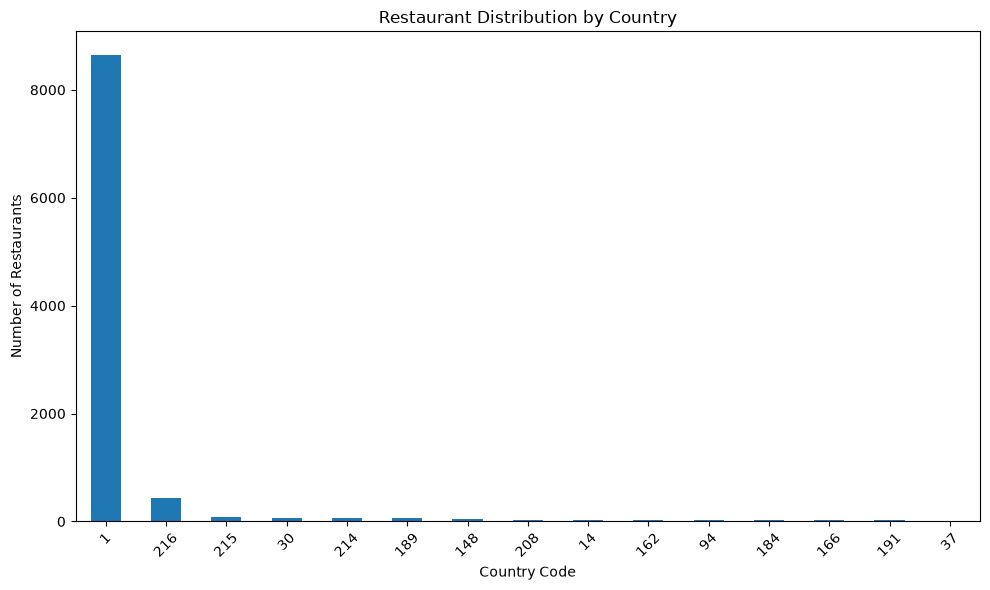

In [14]:
plt.figure(figsize=(10, 6))

country_distribution.head(15).plot(kind="bar")

plt.title("Restaurant Distribution by Country")
plt.xlabel("Country Code")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# city analysis

In [15]:
city_distribution = df["City"].value_counts()

print("Top 20 Cities by Number of Restaurants:")
print(city_distribution.head(20))

Top 20 Cities by Number of Restaurants:
City
New Delhi                 5473
Gurgaon                   1118
Noida                     1080
Faridabad                  251
Ghaziabad                   25
Ahmedabad                   21
Amritsar                    21
Bhubaneshwar                21
Guwahati                    21
Lucknow                     21
Bras�_lia                   20
Rio de Janeiro              20
S��o Paulo                  20
Albany                      20
Athens                      20
Augusta                     20
Boise                       20
Cedar Rapids/Iowa City      20
Columbus                    20
Dalton                      20
Name: count, dtype: int64


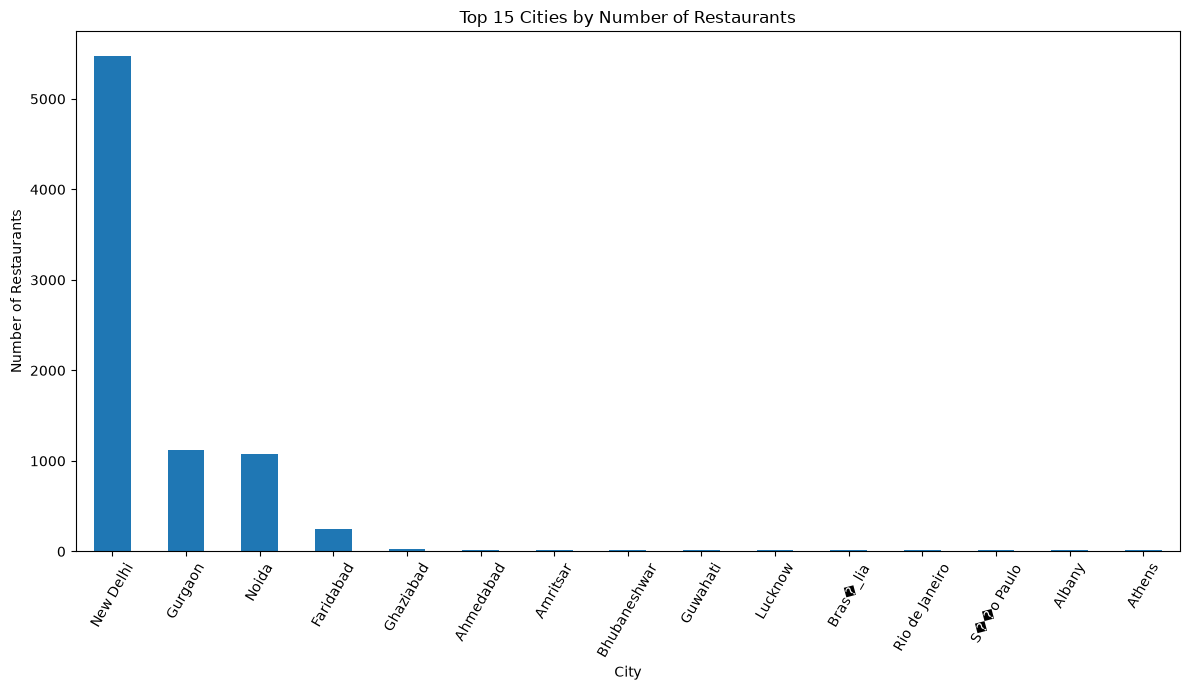

In [16]:
plt.figure(figsize=(12, 7))

city_distribution.head(15).plot(kind="bar")

plt.title("Top 15 Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

# Location vs rating

In [17]:
location_rating_correlation = df[
    ["Latitude", "Longitude", "Aggregate rating"]
].corr()

print(location_rating_correlation)

                  Latitude  Longitude  Aggregate rating
Latitude          1.000000   0.043207          0.000516
Longitude         0.043207   1.000000         -0.116818
Aggregate rating  0.000516  -0.116818          1.000000


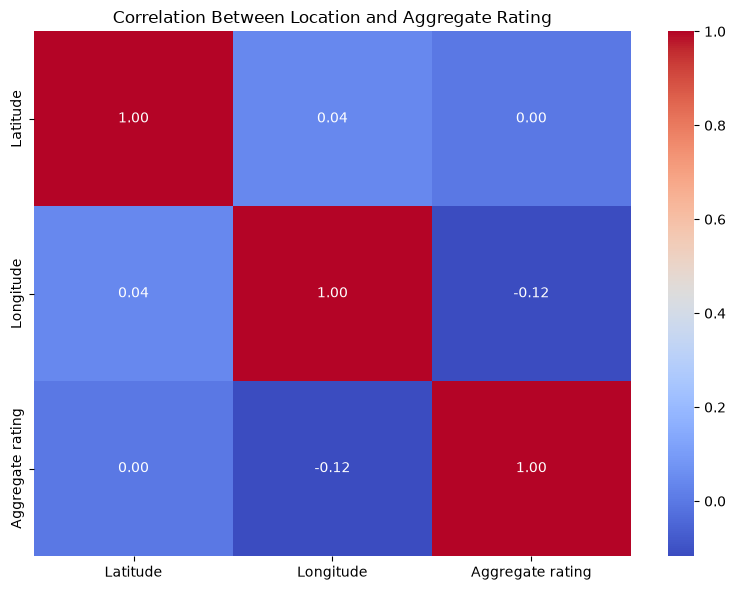

In [18]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    location_rating_correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Location and Aggregate Rating")
plt.tight_layout()
plt.show()

# City rating analysis

In [19]:
city_rating = (
    df.groupby("City")["Aggregate rating"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

city_rating_filtered = city_rating[
    city_rating["count"] >= 10
].sort_values("mean", ascending=False)

city_rating_filtered.head(20)

,mean,count
City,,
London,4.535000,20
Orlando,4.475000,20
Tampa Bay,4.410000,20
Rest of Hawaii,4.410000,20
Bangalore,4.375000,20
Dubai,4.370000,20
Jakarta,4.356250,16
Hyderabad,4.344444,18
Chennai,4.315000,20


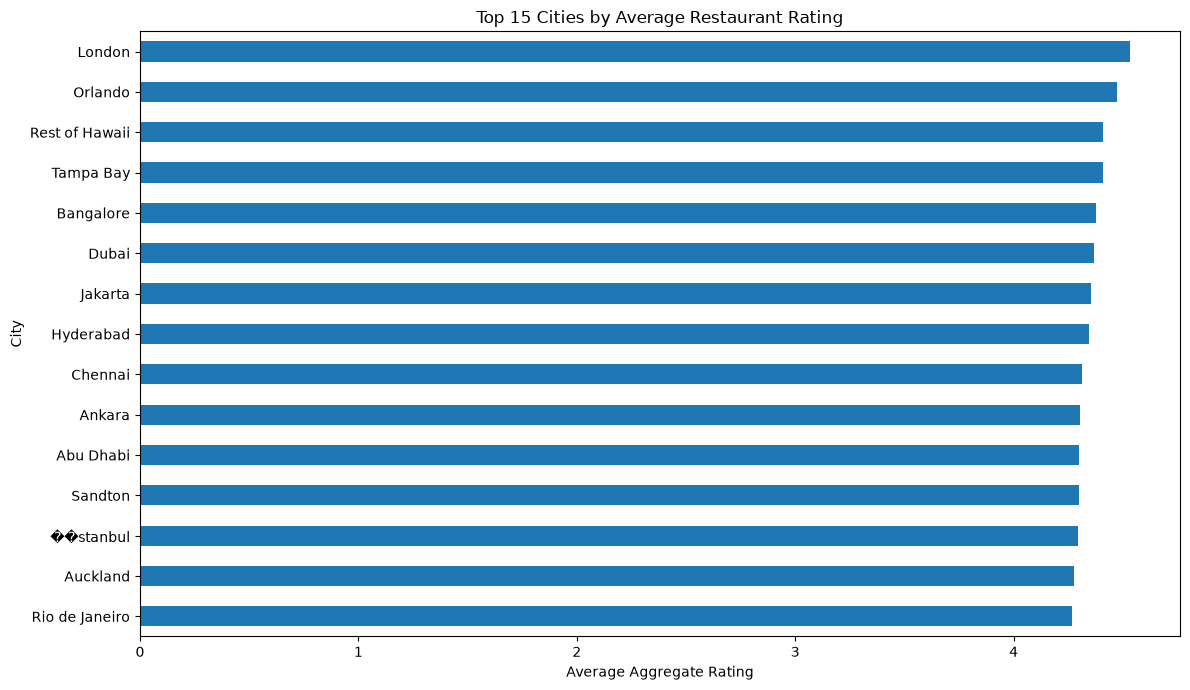

In [20]:
plt.figure(figsize=(12, 7))

city_rating_filtered.head(15)["mean"].sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Cities by Average Restaurant Rating")
plt.xlabel("Average Aggregate Rating")
plt.ylabel("City")

plt.tight_layout()
plt.show()

# the analysis outputs

In [21]:
city_rating_filtered.to_csv(
    "../Outputs/city_average_ratings.csv"
)

location_rating_correlation.to_csv(
    "../Outputs/location_rating_correlation.csv"
)

print("Task 3 outputs saved successfully.")

Task 3 outputs saved successfully.
